# Addestramento e valutazione del classificatore per predirre interazioni tra snoRNA (small nucleolar RNA) e lncRNA (long non-coding RNA)

#### carichiamo le librerie necessarie
#### Una libreria contiene sempre codice python, e mette a disposizione delle funzioni, che svolgono determinati compiti

In [1]:
import os
import pickle
import math
import numpy as np
import pandas as pd
from sklearn.metrics import (accuracy_score,
                             precision_recall_fscore_support,
                             confusion_matrix)
from sklearn.metrics import matthews_corrcoef
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

#### Carichiamo i dati di training e test, insieme alle rappresentazioni delle molecole, estratte da un RNA-Language Model (RNA-FM)

In [2]:
folds_dir = f"/content/folds" # Questa directory deve contenere il file 'fold_0', dove sono salvate le sequenze di training e test
dict_path = '/content/snorna-lncrna_dictionary_pooled_embeddings_RNAFM.p'   # Questo file contiene per ogni sequenza di RNA nel dataset, una rappresentazione estratta da RNA-FM

# training e test
if os.path.isdir(folds_dir):
    files = sorted([p for p in os.listdir(folds_dir) if p.endswith('.pkl')])
    fold = []
    for fn in files:
        with open(os.path.join(folds_dir, fn), 'rb') as fh:
            fold.append(pickle.load(fh))
    print(f"Loaded {len(fold)} per-fold pickles from {folds_dir}")
    fold = fold[0]
else:
    raise FileNotFoundError(f"directory {folds_dir} not found.")

# embeddings
if not os.path.exists(dict_path):
    raise FileNotFoundError(f"Embeddings dict not found at {dict_path}")
with open(dict_path, 'rb') as fh:
    embeddings_dict = pickle.load(fh)
print("Loaded embeddings dict with", len(embeddings_dict), "entries")

Loaded 1 per-fold pickles from /content/folds
Loaded embeddings dict with 1102 entries


La prossima parte di codice serve a definire delle funzioni utili per l'addestramento del classificatore.

In [3]:
input_dimension = 2560  # final input expected (from embeddings)
patience = 10

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", device)

# Convert pair lists into numpy arrays (embeddings) and labels
def pairs_to_arrays(pairs_list, embeddings_dict, label):
    X_list = []
    y_list = []
    missing = 0
    for (s1, s2), (t1, t2) in pairs_list:
        if s1 not in embeddings_dict or s2 not in embeddings_dict:
            missing += 1
            continue
        e1 = np.asarray(embeddings_dict[s1], dtype=np.float32)
        e2 = np.asarray(embeddings_dict[s2], dtype=np.float32)
        e1s = e1
        e2s = e2
        if e1s.shape[0] < 1280 or e2s.shape[0] < 1280:
            # if shorter than 640, pad with zeros to 640 to keep shape consistent
            e1s = np.pad(e1s, (1280 - e1s.shape[0], 0), mode='constant') if e1s.shape[0] < 1280 else e1s
            e2s = np.pad(e2s, (1280 - e2s.shape[0], 0), mode='constant') if e2s.shape[0] < 1280 else e2s
        X_list.append(np.concatenate([e1s, e2s], axis=0))
        y_list.append(int(label))
    if missing:
        print(f"  Skipped {missing} pairs due to missing embeddings.")
    if len(X_list) == 0:
        return None, None
    X = np.stack(X_list)
    y = np.array(y_list, dtype=np.int64)
    return X, y

# Balanced batch sampler (same logic as notebook)
def get_data_loaders_without_replacement_from_arrays(X_train, y_train, X_valid, y_valid, batch_size):
    """
    Build DataLoaders using BalancedBatchSampler logic but from numpy arrays.
    """
    train_tensor = torch.from_numpy(X_train).float()
    train_labels = torch.from_numpy(y_train)
    train_dataset = TensorDataset(train_tensor, train_labels)

    valid_tensor = torch.from_numpy(X_valid).float()
    valid_labels = torch.from_numpy(y_valid)
    valid_dataset = TensorDataset(valid_tensor, valid_labels)

    class BalancedBatchSampler:
        def __init__(self, labels, batch_size, neg_batch_ratio):
            self.labels = labels.numpy() if torch.is_tensor(labels) else labels
            self.batch_size = batch_size
            self.neg_batch_ratio = neg_batch_ratio
            self.neg_indices = np.where(self.labels == 0)[0]
            self.pos_indices = np.where(self.labels == 1)[0]
            self.num_neg_per_batch = int(batch_size * neg_batch_ratio)
            self.num_batches = len(self.neg_indices) // max(1, self.num_neg_per_batch)
            self.leftover_negatives = len(self.neg_indices) % max(1, self.num_neg_per_batch)

        def __iter__(self):
            neg_idx = np.random.permutation(self.neg_indices)
            pos_idx = self.pos_indices
            batch_start = 0
            for batch_num in range(self.num_batches):
                if batch_num < self.num_batches - 1 or self.leftover_negatives == 0:
                    num_neg_in_batch = self.num_neg_per_batch
                else:
                    num_neg_in_batch = self.leftover_negatives
                neg_batch = neg_idx[batch_start:batch_start + num_neg_in_batch]
                batch_start += num_neg_in_batch
                num_pos_in_batch = self.batch_size - num_neg_in_batch
                pos_batch = np.random.choice(pos_idx, num_pos_in_batch, replace=True)
                batch_indices = np.concatenate([neg_batch, pos_batch])
                np.random.shuffle(batch_indices)
                yield batch_indices.tolist()

        def __len__(self):
            return self.num_batches if self.num_batches > 0 else 1

    train_sampler = BalancedBatchSampler(train_labels, batch_size, neg_batch_ratio=0.5)
    train_loader = DataLoader(train_dataset, batch_sampler=train_sampler, num_workers=2)
    valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    return train_loader, valid_loader

# learning rate scheduler with warmup
def cosine_annealing_with_warmup(epoch, warmup_epochs=4, max_epochs=50, min_lr=1e-5):
    if epoch < warmup_epochs:
        return (epoch + 1) / warmup_epochs
    else:
        cosine_decay = 0.5 * (1 + math.cos(math.pi * (epoch - warmup_epochs) / (max_epochs - warmup_epochs)))
        return (cosine_decay * (1 - min_lr) + min_lr)

Device: cuda


## Iperparametri
Quando una rete neurale viene addestrata, oltre ai dati in input, bisogna definire le specifiche della rete stessa, come per esempio: quanti esempi guardare ogni volta (batch size), o quante volde guardare l'intero dataset (epochs).

In [4]:
# iper-parametri
batch_size = 512
validation_split_ratio = 0.2
learning_rate = 0.0005
num_layers = 4
dropout = 0.2
hidden_dimension = 1024
min_lr = 5e-5
epochs = 50

Ora definiamo il classificatore nel codice

In [5]:
# InteractionNN
class InteractionNN(nn.Module):
    def __init__(self, input_dim=input_dimension, hidden_dim=hidden_dimension, num_layers=num_layers, dropout=dropout):
        super(InteractionNN, self).__init__()
        layers = [nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Dropout(p=dropout)]
        for _ in range(num_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(p=dropout))
        self.hidden_layers = nn.Sequential(*layers)
        self.output_layer = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.hidden_layers(x)
        x = self.output_layer(x)
        return torch.sigmoid(x).view(-1)

In [6]:
# ----------------------------
# Preparazione dati (train / test)
# ----------------------------
print("\n=== Fold singolo ===")
positivi_train = fold['train']['positives']
negativi_train = fold['train']['negatives']
positivi_test  = fold['test']['positives']
negativi_test  = fold['test']['negatives']

# Costruzione array di training
Xp, yp = pairs_to_arrays(positivi_train, embeddings_dict, label=1)
Xn, yn = pairs_to_arrays(negativi_train, embeddings_dict, label=0)

X_all = np.concatenate([Xp, Xn], axis=0)
y_all = np.concatenate([yp, yn], axis=0)

# ----------------------------
# Split train / validation
# ----------------------------
n_tot = len(y_all)
n_train = int((1 - validation_split_ratio) * n_tot)

indici = np.arange(n_tot)
np.random.shuffle(indici)

train_idx = indici[:n_train]
val_idx   = indici[n_train:]

X_train = X_all[train_idx]
y_train = y_all[train_idx]
X_val   = X_all[val_idx]
y_val   = y_all[val_idx]

# Standardizzazione (fit solo su train)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)

# ----------------------------
# Preparazione test set
# ----------------------------
Xp_test, yp_test = pairs_to_arrays(positivi_test, embeddings_dict, label=1)
Xn_test, yn_test = pairs_to_arrays(negativi_test, embeddings_dict, label=0)

X_test = np.concatenate([Xp_test, Xn_test], axis=0)
y_test = np.concatenate([yp_test, yn_test], axis=0)

X_test = scaler.transform(X_test)

# ----------------------------
# DataLoader
# ----------------------------
train_loader, val_loader = get_data_loaders_without_replacement_from_arrays(
    X_train, y_train, X_val, y_val,
    batch_size=batch_size
)

test_ds = TensorDataset(
    torch.from_numpy(X_test).float(),
    torch.from_numpy(y_test)
)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2)

# ----------------------------
# Istanziamento del Modello
# ----------------------------
model = InteractionNN(
    input_dim=input_dimension,
    hidden_dim=hidden_dimension,
    num_layers=num_layers,
    dropout=dropout
).to(device)

optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=lambda e: cosine_annealing_with_warmup(
        e, epochs
    )
)
criterion = nn.BCELoss()



=== Fold singolo ===


In [7]:
# ----------------------------
# Training
# ----------------------------
best_val_loss = float("inf")
best_state = None
epoche_senza_miglioramento = 0

for epoch in range(epochs):
    # ---- Train ----
    model.train()
    loss_train = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device, dtype=torch.float32)

        optimizer.zero_grad()
        output = model(xb).view(-1)
        loss = criterion(output, yb)
        loss.backward()
        optimizer.step()

        loss_train += loss.item()

    loss_train /= len(train_loader)

    # ---- Validation ----
    model.eval()
    loss_val = 0.0
    val_probs = []
    val_labels = []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device, dtype=torch.float32)

            output = model(xb).view(-1)
            loss = criterion(output, yb)

            loss_val += loss.item()
            val_probs.extend(output.cpu().numpy())
            val_labels.extend(yb.cpu().numpy())

    loss_val /= len(val_loader)

    # Early stopping
    if loss_val < best_val_loss:
        best_val_loss = loss_val
        best_state = model.state_dict()
        epoche_senza_miglioramento = 0
    else:
        epoche_senza_miglioramento += 1

    scheduler.step()
    lr_corrente = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train={loss_train:.4f} | Val={loss_val:.4f} | LR={lr_corrente:.2e}"
    )

    if epoche_senza_miglioramento >= patience:
        print("Early stopping")
        break

# Ripristino miglior modello
model.load_state_dict(best_state)

# ----------------------------
# Soglia ottimale su validation (MCC)
# ----------------------------
val_probs = np.array(val_probs)
val_labels = np.array(val_labels)

soglie = np.linspace(0, 1, 101)
mcc = [
    matthews_corrcoef(val_labels, (val_probs > t).astype(int))
    for t in soglie
]
best_thr = soglie[np.nanargmax(mcc)]
print("Soglia ottimale:", best_thr)



Epoch 1/50 | Train=0.6928 | Val=0.6918 | LR=2.00e-05
Epoch 2/50 | Train=0.6904 | Val=0.6887 | LR=3.00e-05
Epoch 3/50 | Train=0.6862 | Val=0.6825 | LR=4.00e-05
Epoch 4/50 | Train=0.6779 | Val=0.6689 | LR=5.00e-05
Epoch 5/50 | Train=0.6576 | Val=0.6370 | LR=6.00e-05
Epoch 6/50 | Train=0.6077 | Val=0.5698 | LR=7.00e-05
Epoch 7/50 | Train=0.5200 | Val=0.4986 | LR=8.00e-05
Epoch 8/50 | Train=0.4556 | Val=0.5037 | LR=9.00e-05
Epoch 9/50 | Train=0.4323 | Val=0.4840 | LR=1.00e-04
Epoch 10/50 | Train=0.3996 | Val=0.4332 | LR=1.10e-04
Epoch 11/50 | Train=0.3566 | Val=0.4331 | LR=1.20e-04
Epoch 12/50 | Train=0.3247 | Val=0.4264 | LR=1.30e-04
Epoch 13/50 | Train=0.2942 | Val=0.4614 | LR=1.40e-04
Epoch 14/50 | Train=0.2763 | Val=0.4406 | LR=1.50e-04
Epoch 15/50 | Train=0.2508 | Val=0.4855 | LR=1.60e-04
Epoch 16/50 | Train=0.2423 | Val=0.5034 | LR=1.70e-04
Epoch 17/50 | Train=0.2256 | Val=0.4790 | LR=1.80e-04
Epoch 18/50 | Train=0.2385 | Val=0.5076 | LR=1.90e-04
Epoch 19/50 | Train=0.2110 | Val=0.43

# Test del modello
## Il classificatore è stato addestrato sui dati di training, ora possiamo testare il suo funzionamento su dati che non ha mai visto: in questo modo possiamo capire se il classificatore può generalizzare a tutte le coppie di miRNA e lncRNA che gli daremo in input.

In [8]:
# ----------------------------
# Test
# ----------------------------
model.eval()
test_probs = []
test_labels = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        output = model(xb).view(-1)
        test_probs.extend(output.cpu().numpy())
        test_labels.extend(yb.numpy())

test_probs = np.array(test_probs)
test_labels = np.array(test_labels)
test_pred = (test_probs > best_thr).astype(int)


Metriche test: {'accuracy': 0.8370927318295739, 'precision': 0.7777777777777778, 'recall': 0.945}


,accuracy,precision,recall
0,0.837093,0.777778,0.945


# Accuratezza del modello sui dati di test
L'accuratezza del modello sui dati di test è una metrica che indica quanto il modello è in grado di fare previsioni corrette su dati che non ha mai visto durante la fase di addestramento. In pratica, è la percentuale di previsioni esatte (sia interazioni positive che negative) che il modello fa su un set di dati indipendente, chiamato 'test set'.

È importante valutarla sui dati di test e non sui dati di training, perché l'accuratezza sul training set potrebbe essere fuorviante: un modello potrebbe aver semplicemente memorizzato i dati di addestramento (overfitting) e non essere in grado di generalizzare a nuove situazioni.

Una buona accuratezza sui dati di test suggerisce che il modello ha imparato pattern utili e può essere utilizzato per fare previsioni affidabili su nuove osservazioni.

### Precisione (Precision)

La **Precisione** misura la proporzione di identificazioni positive che sono state effettivamente corrette. In altre parole, risponde alla domanda: "Di tutte le volte che il modello ha predetto 'Positivo', quante volte aveva ragione?".

È particolarmente importante in casi dove il costo di un falso positivo è alto (es. diagnosi medica: non vogliamo dire a una persona sana che è malata).

**Formula:**

$Precision = \frac{True Positives}{True Positives + False Positives}$

Dove:
- **True Positives (TP)**: Casi positivi correttamente identificati dal modello.
- **False Positives (FP)**: Casi negativi erroneamente identificati come positivi dal modello.

### Richiamo (Recall / Sensibilità)

Il **Richiamo**, o sensibilità, misura la proporzione di casi positivi effettivi che sono stati correttamente identificati dal modello. Risponde alla domanda: "Di tutti i veri casi 'Positivi', quanti il modello è riuscito a identificare correttamente?".

È cruciale in scenari dove il costo di un falso negativo è alto (es. rilevamento di frodi o malattie gravi: non vogliamo perdere un vero positivo).

**Formula:**

$Recall = \frac{True Positives}{True Positives + False Negatives}$

Dove:
- **True Positives (TP)**: Casi positivi correttamente identificati dal modello.
- **False Negatives (FN)**: Casi positivi erroneamente identificati come negativi dal modello.

In [ ]:
# Metriche
risultati = {
    "accuracy": accuracy_score(test_labels, test_pred),
    "precision": precision_recall_fscore_support(
        test_labels, test_pred, average="binary", zero_division=0
    )[0],
    "recall": precision_recall_fscore_support(
        test_labels, test_pred, average="binary", zero_division=0
    )[1],
}

print("Metriche test:", risultati)
display(pd.DataFrame([risultati]))

### Matrice di Confusione

La **Matrice di Confusione** è uno strumento fondamentale per la valutazione delle prestazioni di un modello di classificazione. È una tabella che visualizza e riassume le prestazioni di un algoritmo di classificazione, mettendo a confronto i valori reali (ground truth) con quelli predetti dal modello.

In una matrice di confusione per un problema di classificazione binaria (come il nostro, dove si predice interazione o non interazione), si trovano tipicamente quattro valori:

*   **True Positives (TP)**: Il modello ha predetto correttamente la classe positiva. (Es. Ha predetto 'interazione' e c'era effettivamente un'interazione).
*   **True Negatives (TN)**: Il modello ha predetto correttamente la classe negativa. (Es. Ha predetto 'nessuna interazione' e non c'era effettivamente un'interazione).
*   **False Positives (FP)**: Il modello ha predetto erroneamente la classe positiva quando in realtà era negativa (errore di tipo I). (Es. Ha predetto 'interazione' ma non c'era).
*   **False Negatives (FN)**: Il modello ha predetto erroneamente la classe negativa quando in realtà era positiva (errore di tipo II). (Es. Ha predetto 'nessuna interazione' ma c'era un'interazione).

L'immagine generata dal codice qui sotto, mostra la matrice di confusione **normalizzata**, il che significa che i valori sono espressi come percentuali sul totale dei casi reali per ogni classe. Questo è utile per capire le proporzioni degli errori e dei successi rispetto alla distribuzione delle classi.

Ad esempio, nella matrice visualizzata in precedenza:
*   Il valore in alto a sinistra rappresenta i True Negatives (TN).
*   Il valore in alto a destra rappresenta i False Positives (FP).
*   Il valore in basso a sinistra rappresenta i False Negatives (FN).
*   Il valore in basso a destra rappresenta i True Positives (TP).

In [9]:
# Colors / fonts
color_green = '#88B04B'
color_red = '#FF765B'
font_ticks = 16
font_labels = 18
custom_cmap = LinearSegmentedColormap.from_list("soft_oranges", ['#88B04B', '#204900', '#102A00'])

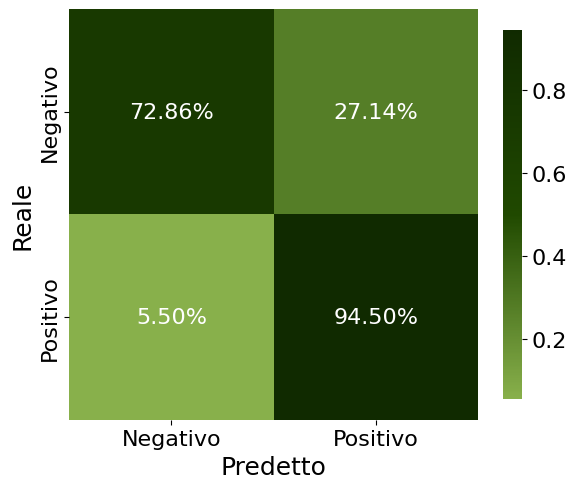

In [10]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_labels, test_pred, normalize="true")

plt.figure(figsize=(6, 5))
ax = sns.heatmap(
    cm,
    annot=True,
    fmt=".2%",
    cmap=custom_cmap,
    xticklabels=["Negativo", "Positivo"],
    yticklabels=["Negativo", "Positivo"],
    annot_kws={"size": font_ticks},
    cbar_kws={"shrink": 0.9}
)

plt.xlabel("Predetto", fontsize=font_labels)
plt.ylabel("Reale", fontsize=font_labels)
plt.xticks(fontsize=font_ticks)
plt.yticks(fontsize=font_ticks)

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_tick_params(labelsize=font_ticks)

plt.tight_layout()
plt.show()


###  Boxplot delle Probabilità Predette

Il boxplot visualizza la distribuzione delle probabilità predette dal modello per le due classi: 'Negativo' (interazioni non presenti) e 'Positivo' (interazioni presenti).

**Componenti del Boxplot:**
*   **Box (scatola)**: Rappresenta il range interquartile (IQR), ovvero il 50% centrale dei dati. Il bordo inferiore della scatola è il primo quartile (Q1), mentre il bordo superiore è il terzo quartile (Q3).
*   **Linea all'interno della scatola**: Indica la mediana (Q2), ovvero il valore centrale della distribuzione.
*   **Baffi (whiskers)**: Si estendono dal box e mostrano la variabilità dei dati al di fuori dell'IQR.
*   **Punti esterni (outliers)**: Rappresentano i valori che cadono al di fuori dei baffi e sono considerati anomali.

**Interpretazione nel contesto delle probabilità predette:**

*   **Boxplot per la classe 'Negativo' (rosso)**: Idealmente, ci aspettiamo che la maggior parte delle probabilità predette per le interazioni non presenti siano vicine a 0. Un boxplot con la scatola e i baffi concentrati vicino a 0 indica che il modello è confidente nel classificare queste istanze come negative.
*   **Boxplot per la classe 'Positivo' (verde)**: Idealmente, ci aspettiamo che la maggior parte delle probabilità predette per le interazioni presenti siano vicine a 1. Un boxplot con la scatola e i baffi concentrati vicino a 1 indica che il modello è confidente nel classificare queste istanze come positive.

Più i boxplot sono ristretti e spostati verso gli estremi (0 e 1 per le rispettive classi), più il modello è confidente. Al contrario, una maggiore dispersione o una concentrazione delle probabilità attorno alla soglia indica una minore sicurezza nelle previsioni del modello.

/tmp/ipython-input-1521446189.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


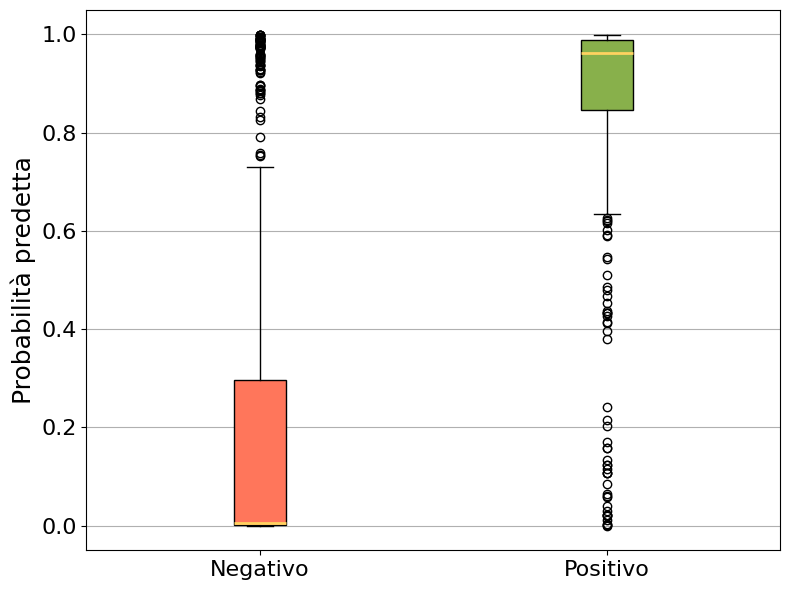

In [11]:
plt.figure(figsize=(8, 6))

box = plt.boxplot(
    [
        test_probs[test_labels == 0],
        test_probs[test_labels == 1]
    ],
    labels=["Negativo", "Positivo"],
    patch_artist=True
)

# Colori classi
box["boxes"][0].set(facecolor=color_red)    # Negativi
box["boxes"][1].set(facecolor=color_green)  # Positivi

# Linea della mediana
for median in box["medians"]:
    median.set(color="#FFD260", linewidth=2)

plt.ylabel("Probabilità predetta", fontsize=font_labels)
plt.xticks(fontsize=font_ticks)
plt.yticks(fontsize=font_ticks)
plt.grid(axis="y")
plt.tight_layout()
plt.show()


# Esercizio: Modifica degli Iperparametri e Analisi dei Risultati

Per esplorare l'impatto degli iperparametri sulle prestazioni del modello, seguire i seguenti passaggi:

1.  **Modifica degli Iperparametri**: Modificare i valori di `batch_size` ed `epochs` nella cella di codice dove sono definiti gli iperparametri. Si consiglia di provare diversi valori per osservare come influenzano il training e i risultati.

2.  **Riaddestramento del Modello**: Eseguire nuovamente tutte le celle di codice a partire dalla definizione degli iperparametri fino al plotting dei grafici (incluse le celle di training e test del modello) per addestrare il modello con i nuovi valori.

3.  **Valutazione dei Nuovi Risultati**: Osservare le metriche di accuratezza, precisione e recall calcolate per il modello riaddestrato.

5.  **Documentazione delle Differenze**: In una nuova cella di testo (o commenti nel codice), documentare le differenze osservate in termini di:
    *   **Accuratezza, Precisione e Recall**: Sono migliorate o peggiorate? Di quanto?

L'obiettivo è comprendere come le modifiche a `batch_size` ed `epochs` influenzino la capacità del modello di apprendere e generalizzare sulle interazioni snoRNA-lncRNA.

Attenzione! se una cella di codice viene ri-eseguita, i risultati si perdono! Quindi è meglio iniziare a scrivere i risultati attuali, e poi descrivere come vengono cambiati gli ipermarametri e i nuovi risultati.